<a href="https://colab.research.google.com/github/SruthiGS-Gito/Case-Study---Assignment-MLAI-B3/blob/main/Case_Study_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import os

import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

print(X_train.shape)
print(y_train.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1890s 11us/step
(50000, 32, 32, 3)
(50000, 1)


In [3]:
# Image Normalization

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
num_classes = 100

Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


## Build CNN

In [6]:
custom_model = tf.keras.Sequential([
    # input Layer ~ Original Data
    tf.keras.layers.Input(shape=(32, 32, 3)),
    # shape (32x32)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

In [7]:
# Compilation
custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# Early stopping
early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [9]:
# Checkpointing
checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

In [14]:
# Train the Model
history = custom_model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early, checkpoint],
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.2767 - loss: 2.9120 - val_accuracy: 0.3008 - val_loss: 2.8268
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.2772 - loss: 2.8942 - val_accuracy: 0.3121 - val_loss: 2.7792
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.2814 - loss: 2.8812 - val_accuracy: 0.2900 - val_loss: 2.9224
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.2853 - loss: 2.8673 - val_accuracy: 0.3442 - val_loss: 2.6343
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.2879 - loss: 2.8546 - val_accuracy: 0.2525 - val_loss: 3.0850
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.2918 - loss: 2.8378 - val_accuracy: 0.3275 - val_loss: 2.7127
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.2950 - loss: 2.8160 - val_accuracy: 0.3449 - val_loss: 2.6321
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.2926 - loss: 2.8134 - 

## Plots

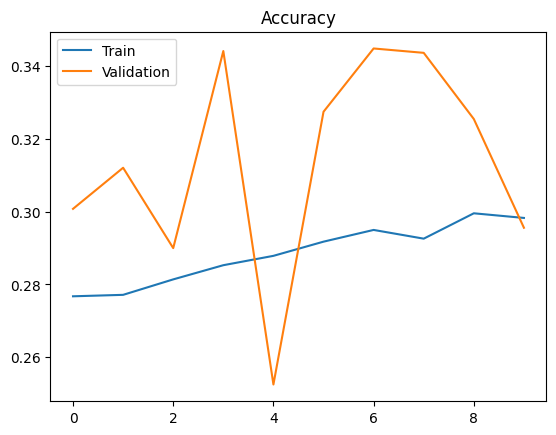

In [15]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

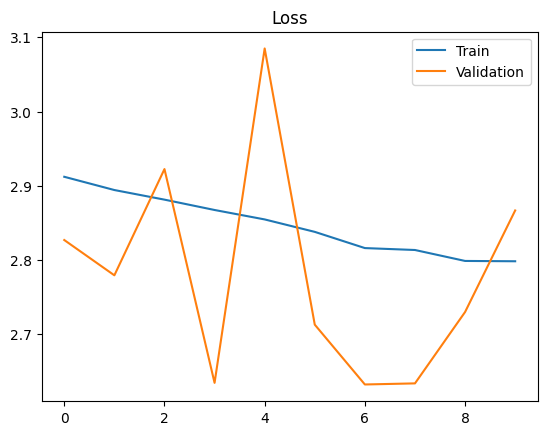

In [18]:
# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

In [21]:
custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517,230 (1.97 MB)

 Trainable params: 172,260 (672.89 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 344,522 (1.31 MB)

## VGG

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Resize
X_train_resize = tf.image.resize(X_train, (224,224)).numpy()
X_test_resize = tf.image.resize(X_test, (224,224)).numpy()

In [1]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

vgg = Sequential([
    Input(shape=(224,224,3)),
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

vgg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,611,556 (105.33 MB)

 Trainable params: 12,896,868 (49.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [3]:
from tensorflow.keras.optimizers import Adam

vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Resize VGG16
X_train_resize = tf.image.resize(
    X_train,
    (224,224)
).numpy()

X_test_resize = tf.image.resize(
    X_test,
    (224,224)
).numpy()

# Early stopping
early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history_vgg = vgg.fit(
    X_train_resize,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early],
    verbose=1
)

# Evaluate
loss_vgg, acc_vgg = vgg.evaluate(
    X_test_resize,
    y_test,
    verbose=1
)

print("Test Loss :", loss_vgg)
print("Test Accuracy :", acc_vgg)

In [1]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['val_accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

plt.legend(['Custom CNN','VGG16'])
plt.title("Validation Accuracy Comparison")
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>